In [298]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [299]:
columns_headers = [
    "time", "gender", "highschool_%", "study_year","faculty","ung_grade_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
df = pd.read_csv("/Users/bhijanbastola/Desktop/intern/Data/Stats survey.csv", names=columns_headers, header=0)

In [300]:
df.head()

,time,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [301]:
df.dtypes

time                object
gender              object
highschool_%       float64
study_year          object
faculty             object
ung_grade_2023     float64
accomodation        object
allowance           object
scholarship         object
study_hours         object
party_week          object
drinks_night        object
missed_classes      object
failed_classes      object
in_relationship     object
parent_approve      object
relation_parent     object
dtype: object

/Users/bhijanbastola/Desktop/intern/100/lib/python3.10/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname EET identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/Users/bhijanbastola/Desktop/intern/100/lib/python3.10/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname EET identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


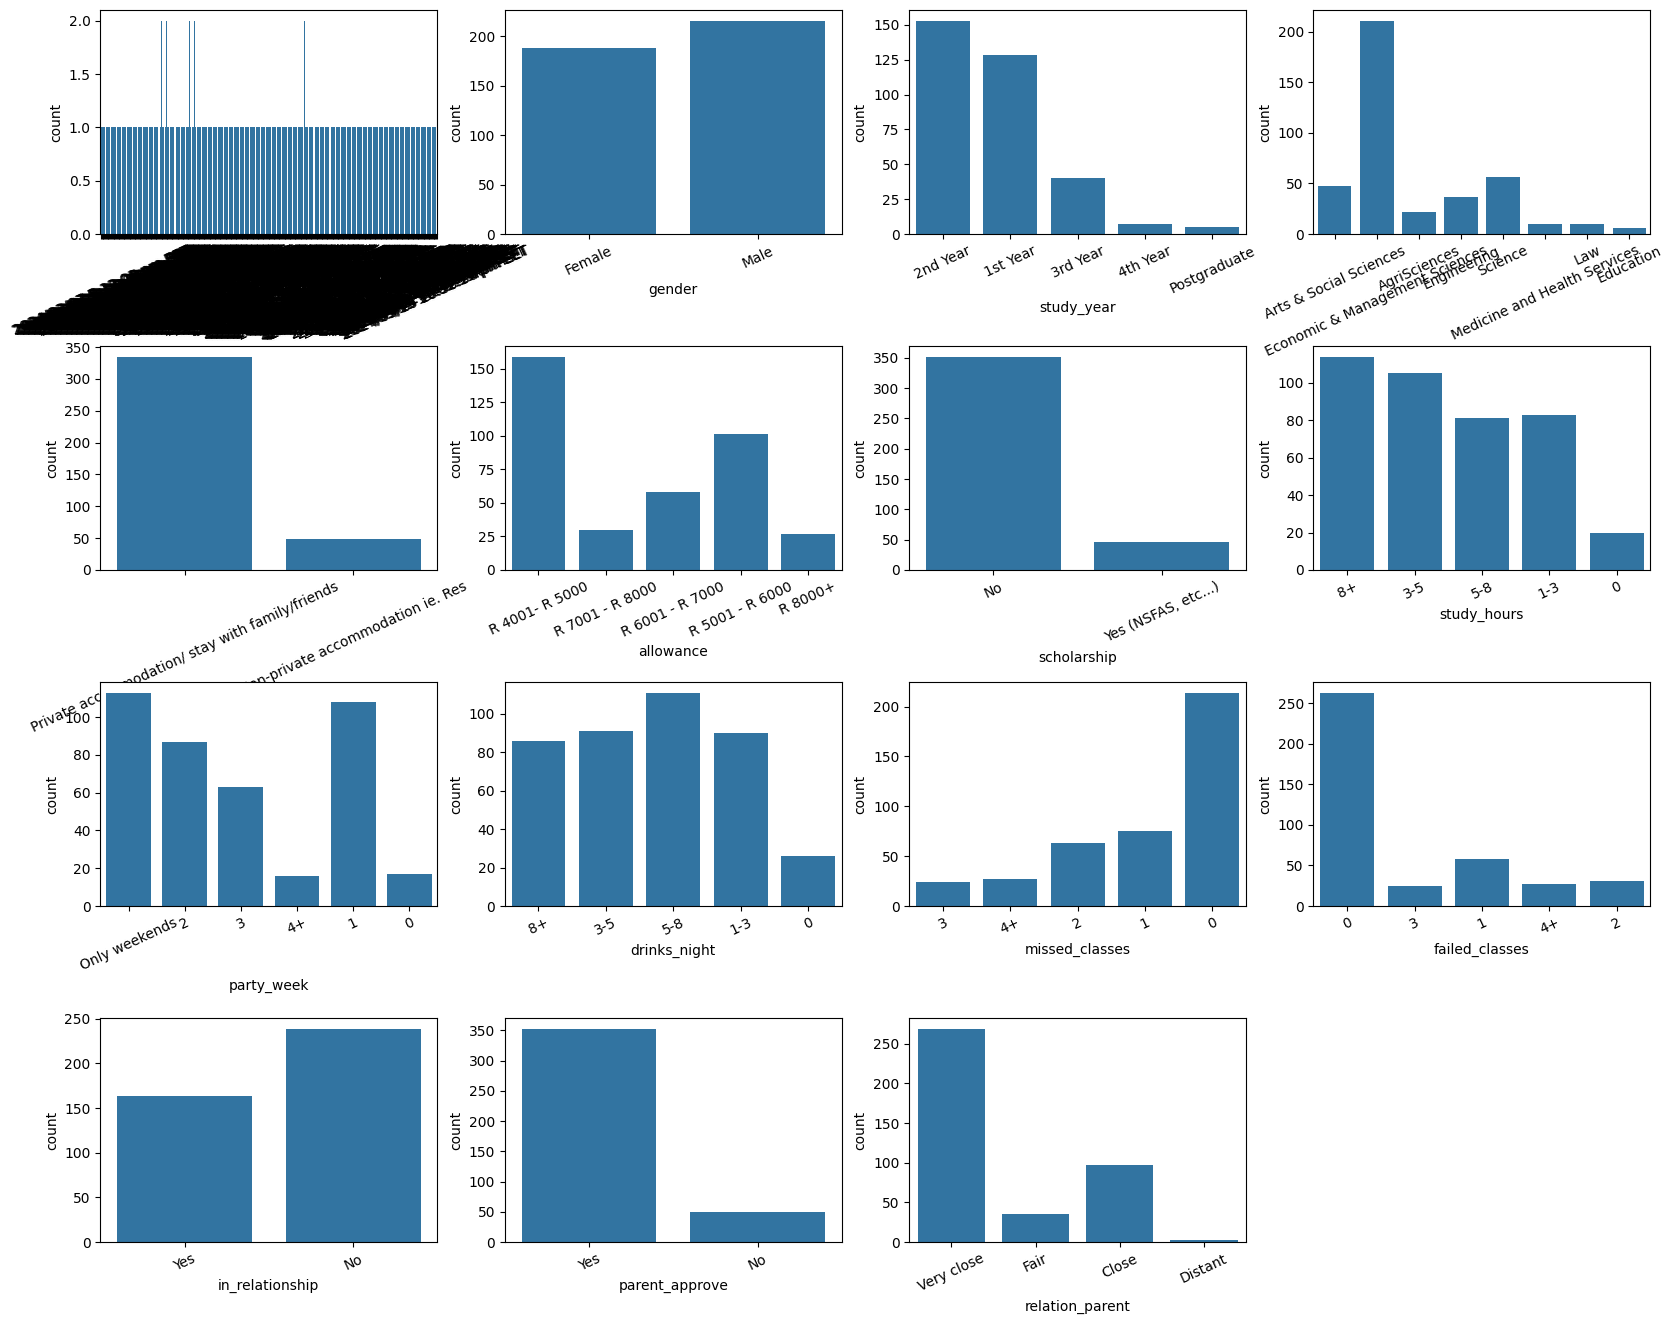

In [302]:
fig=plt.figure(figsize=(20,16))
sayac=1
for i in df.select_dtypes(include="object").columns:
    fig.add_subplot(4,4,sayac)
    sns.countplot(df,x=i)
    plt.xticks(rotation=25)
    sayac+=1
    plt.subplots_adjust(hspace=0.5)
plt.show()

In [303]:
df.isna().sum()

time                0
gender              2
highschool_%        7
study_year         73
faculty             7
ung_grade_2023     86
accomodation       23
allowance          31
scholarship         8
study_hours         3
party_week          2
drinks_night        2
missed_classes      3
failed_classes      3
in_relationship     3
parent_approve      4
relation_parent     3
dtype: int64

In [304]:
columns = ['study_year', 'gender', 'faculty','accomodation','parent_approve']

df[columns] = df[columns].apply(
    lambda col: col.fillna(col.mode()[0])
)

In [305]:
df['accomodation'].unique()

array(['Private accommodation/ stay with family/friends',
       'Non-private accommodation ie. Res'], dtype=object)

In [306]:
df['allowance'].value_counts()

allowance
R 4001- R 5000     159
R 5001 - R 6000    101
R 6001 - R 7000     58
R 7001 - R 8000     30
R 8000+             27
Name: count, dtype: int64

In [307]:
allowance_mapping = {
    'R 4001- R 5000': 0,
    'R 5001 - R 6000': 1,
    'R 6001 - R 7000': 2,
    'R 7001 - R 8000': 3,
    'R 8000+': 4
}

df['allowance'] = df['allowance'].map(allowance_mapping)

In [308]:
df['allowance'].isna().sum()

np.int64(31)

In [309]:
df['allowance'] = df['allowance'].fillna(df['allowance'].mode()[0])


In [310]:
df['scholarship']=df['scholarship'].fillna(df['scholarship'].mode()[0])

In [311]:
df['scholarship'].isna().sum()

np.int64(0)

In [312]:
df['study_hours'].value_counts()

study_hours
8+     114
3-5    105
1-3     83
5-8     81
0       20
Name: count, dtype: int64

In [313]:
study_hour_mapping = {
    '0': 0,
    '1-3': 1,
    '3-5': 2,
    '5-8': 3,
    '8+': 4
}

df['study_hours'] = df['study_hours'].map(study_hour_mapping)

In [314]:
df['study_hours']=df['study_hours'].fillna(df['study_hours'].mode()[0])

In [315]:
df['study_hours'].isna().sum()

np.int64(0)

In [316]:
df['party_week'].value_counts()

party_week
Only weekends    113
1                108
2                 87
3                 63
0                 17
4+                16
Name: count, dtype: int64

In [317]:
party_mapping = {
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4+': 4,
    'Only weekends': 5
}

df['party_week'] = df['party_week'].astype(str).map(party_mapping)

In [318]:
df['party_week'] = df['party_week'].fillna(df['party_week'].mode()[0])

In [319]:
df['party_week'].isna().sum()

np.int64(0)

In [320]:
df['party_week'].dtype

dtype('float64')

In [321]:
df['drinks_night'].value_counts(dropna=False)

drinks_night
5-8    111
3-5     91
1-3     90
8+      86
0       26
NaN      2
Name: count, dtype: int64

In [322]:
drinks_nights_mapping = {
    '0': 0,
    '1-3': 1,
    '3-5': 2,
    '5-8': 3,
    '8+': 4
}

df['drinks_night'] = df['drinks_night'].astype(str).map(drinks_nights_mapping)

In [323]:
df['drinks_night'].fillna(df['drinks_night'].mode()[0])

0      4.0
1      2.0
2      4.0
3      4.0
4      3.0
      ... 
401    1.0
402    4.0
403    2.0
404    3.0
405    2.0
Name: drinks_night, Length: 406, dtype: float64

In [324]:
df['missed_classes'].value_counts()

missed_classes
0     214
1      75
2      63
4+     27
3      24
Name: count, dtype: int64

In [325]:
missed_class_mapping = {
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4+': 4
}

df['missed_classes'] = df['missed_classes'].astype(str).map(missed_class_mapping)

In [326]:
df['missed_classes']=df['missed_classes'].fillna(df['missed_classes'].mode()[0])

In [327]:
df['missed_classes'].isna().sum()

np.int64(0)

In [328]:
df['failed_classes'].value_counts()

failed_classes
0     263
1      58
2      31
4+     27
3      24
Name: count, dtype: int64

In [329]:
failed_class_mapping = {
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4+': 4
}

df['failed_classes'] = df['failed_classes'].astype(str).map(failed_class_mapping)

In [330]:
df['failed_classes']=df['failed_classes'].fillna(df['failed_classes'].mode()[0])

In [331]:
df['in_relationship'].value_counts()

in_relationship
No     239
Yes    164
Name: count, dtype: int64

In [332]:
df['in_relationship']=df['in_relationship'].fillna(df['in_relationship'].mode()[0])

In [333]:
df['in_relationship'] = df['in_relationship'].map({"Yes": 0, "No": 1})


In [334]:
df['in_relationship'].isna().sum()


np.int64(0)

In [335]:
df['parent_approve'].value_counts()

parent_approve
Yes    357
No      49
Name: count, dtype: int64

In [336]:
df['in_relationship'] = df['in_relationship'].astype(str).map({"Yes": 0, "No": 1})

In [337]:
df['relation_parent'].value_counts()

relation_parent
Very close    269
Close          97
Fair           35
Distant         2
Name: count, dtype: int64

In [338]:
relation_parent_mapping={
    'Very close':0,
    'Close':1,
    'Fair':2,
    'Distant':3
}
df['relation_parent']=df['relation_parent'].map(relation_parent_mapping)

In [339]:
df['relation_parent']=df['relation_parent'].fillna(df['relation_parent'].mode()[0])


In [340]:
df['gender']=df['gender'].map({"Male":0,"Female":1})

In [341]:
study_year_mapping = {
    "1st year": 0,
    "2nd year": 1,
    "3rd year": 2,
    "4th year": 3,
    "Postgrad": 4
}
df['study_year'] = df['study_year'].astype(str).map(study_year_mapping)
 

In [342]:
faculty_mapping = {
    "AgriSciences": 0,
    "Arts & Social Sciences": 1,
    "Economic & Management Sciences": 2,
    "Education": 3,
    "Engineering": 4,
    "Law": 5,
    "Medicine & Health Sciences": 6,
    "Military Science": 7,
    "Science": 8,
    "Theology": 9
}
df['faculty'] = df['faculty'].map(faculty_mapping)

In [343]:
df

,time,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,2024/03/07 5:12:01 pm EET,1,76.0,NaN,1.0,72.0,Private accommodation/ stay with family/friends,0.0,No,4.0,5.0,4.0,3.0,0.0,NaN,Yes,0.0
1,2024/03/07 5:12:08 pm EET,0,89.0,NaN,2.0,75.0,Private accommodation/ stay with family/friends,3.0,"Yes (NSFAS, etc...)",4.0,5.0,2.0,4.0,0.0,NaN,Yes,0.0
2,2024/03/07 5:12:25 pm EET,0,76.0,NaN,0.0,55.0,Private accommodation/ stay with family/friends,0.0,No,2.0,2.0,4.0,3.0,0.0,NaN,Yes,0.0
3,2024/03/07 5:12:28 pm EET,0,89.0,NaN,4.0,84.0,Private accommodation/ stay with family/friends,2.0,No,2.0,3.0,4.0,2.0,0.0,NaN,Yes,0.0
4,2024/03/07 5:13:00 pm EET,1,74.0,NaN,1.0,52.0,Private accommodation/ stay with family/friends,0.0,No,2.0,5.0,3.0,1.0,3.0,NaN,Yes,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,2024/03/12 11:05:33 am EET,1,74.0,NaN,8.0,NaN,Private accommodation/ stay with family/friends,0.0,No,2.0,3.0,1.0,0.0,0.0,NaN,Yes,1.0
402,2024/03/12 3:26:14 pm EET,1,73.0,NaN,2.0,58.0,Private accommodation/ stay with family/friends,2.0,"Yes (NSFAS, etc...)",3.0,1.0,4.0,0.0,0.0,NaN,Yes,0.0
403,2024/03/13 10:32:19 pm EET,1,86.0,NaN,2.0,NaN,Private accommodation/ stay with family/friends,0.0,No,3.0,2.0,2.0,1.0,0.0,NaN,Yes,0.0
404,2024/03/13 10:32:27 pm EET,0,85.0,NaN,2.0,NaN,Private accommodation/ stay with family/friends,0.0,No,1.0,4.0,3.0,4.0,0.0,NaN,Yes,1.0
